## ***Lab Report 2***

### ***Part 1***

PDLS trials found: 10
DDLS trials found: 10


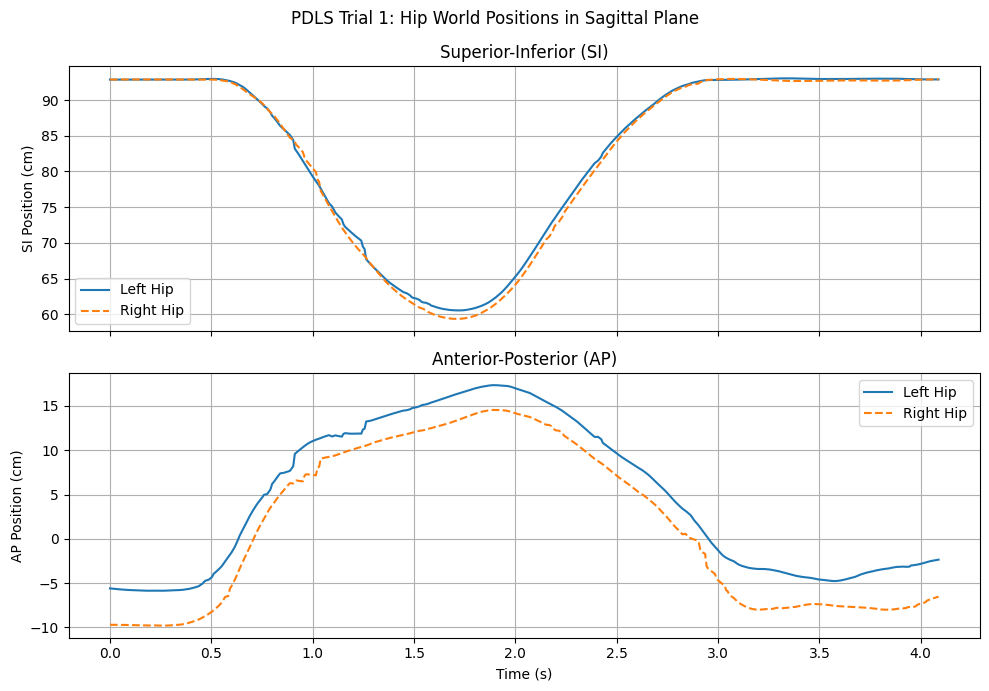

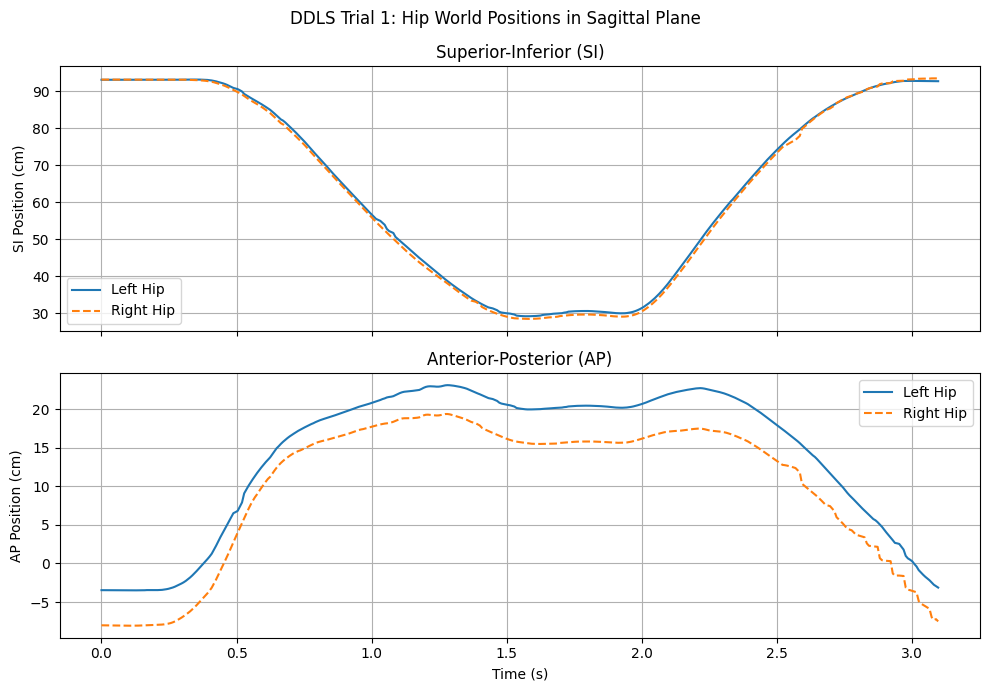

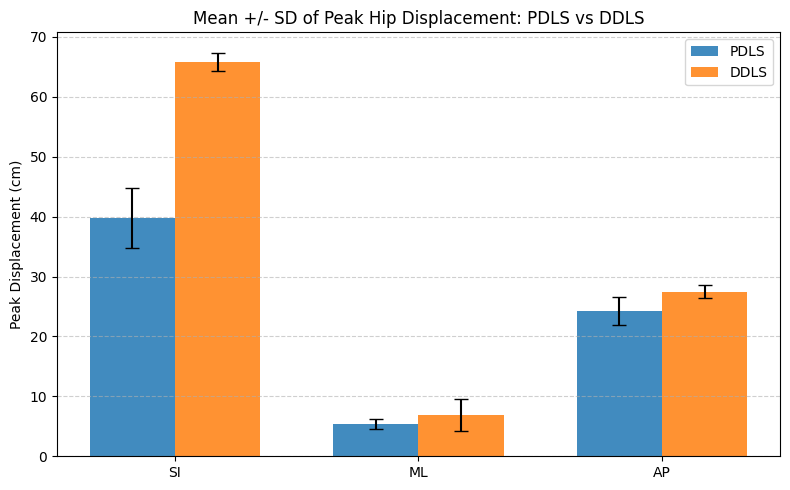

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import bvhio

def get_pos(joint_data, motion, joint_name):
    info = joint_data[joint_name]
    cs = info["col_start"]
    out = {}
    for i, ch in enumerate(info["channels"]):
        if ch in ("Xposition", "Yposition", "Zposition"):
            out[ch] = motion[:, cs + i]
    return out


# ── bvhio-based world-space position loader ──────────────────────────────────
def load_joint_world_pos(filepath, joint_names):
    """
    Returns world-space positions for each named joint across all frames.
    Axis mapping (bvhio/OpenGL right-handed, Y+ up, Z- forward):
      X -> ML,  Y -> SI,  Z -> AP
    Result dict: {joint_name: ndarray shape (n_frames, 3)}
    """
    bvh_meta = bvhio.readAsBvh(filepath)
    n_frames = bvh_meta.FrameCount
    ft = bvh_meta.FrameTime

    root = bvhio.readAsHierarchy(filepath)
    joints = {name: root.filter(name)[0] for name in joint_names}

    positions = {name: np.zeros((n_frames, 3)) for name in joint_names}
    for i in range(n_frames):
        root.loadPose(i)
        for name, jnt in joints.items():
            p = jnt.PositionWorld
            positions[name][i] = [p.x, p.y, p.z]

    return np.arange(n_frames) * ft, positions, ft


def peak_displacements(files):
    """Peak displacement per trial = range (max-min), averaged L & R hip world positions."""
    si_peaks, ml_peaks, ap_peaks = [], [], []
    for fp in files:
        _, pos, _ = load_joint_world_pos(fp, ["LeftUpLeg", "RightUpLeg"])
        left, right = pos["LeftUpLeg"], pos["RightUpLeg"]
        si_peaks.append((np.ptp(left[:, 1]) + np.ptp(right[:, 1])) / 2.0)   # Y = SI
        ml_peaks.append((np.ptp(left[:, 0]) + np.ptp(right[:, 0])) / 2.0)   # X = ML
        ap_peaks.append((np.ptp(left[:, 2]) + np.ptp(right[:, 2])) / 2.0)   # Z = AP
    return np.array(si_peaks), np.array(ml_peaks), np.array(ap_peaks)


def summarize(peaks):
    return {
        "SI_mean": np.mean(peaks[0]), "SI_std": np.std(peaks[0]),
        "ML_mean": np.mean(peaks[1]), "ML_std": np.std(peaks[1]),
        "AP_mean": np.mean(peaks[2]), "AP_std": np.std(peaks[2]),
    }

# Motion 1 = PDLS, Motion 2 = DDLS
data_dir = "data"
pdls_files = sorted(glob.glob(os.path.join(data_dir, "motion_1_*.bvh")))
ddls_files = sorted(glob.glob(os.path.join(data_dir, "motion_2_*.bvh")))

print(f"PDLS trials found: {len(pdls_files)}")
print(f"DDLS trials found: {len(ddls_files)}")

unit_label = "cm"

# (a) PDLS trial 1 – sagittal plane (SI and AP), world positions
t1, pos1, _ = load_joint_world_pos(pdls_files[0], ["LeftUpLeg", "RightUpLeg"])

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("PDLS Trial 1: Hip World Positions in Sagittal Plane")

axes[0].plot(t1, pos1["LeftUpLeg"][:, 1],  label="Left Hip",  color="tab:blue")
axes[0].plot(t1, pos1["RightUpLeg"][:, 1], label="Right Hip", color="tab:orange", linestyle="--")
axes[0].set_ylabel(f"SI Position ({unit_label})")
axes[0].set_title("Superior-Inferior (SI)")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t1, pos1["LeftUpLeg"][:, 2],  label="Left Hip",  color="tab:blue")
axes[1].plot(t1, pos1["RightUpLeg"][:, 2], label="Right Hip", color="tab:orange", linestyle="--")
axes[1].set_ylabel(f"AP Position ({unit_label})")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Anterior-Posterior (AP)")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

# (b) DDLS trial 1
t2, pos2, _ = load_joint_world_pos(ddls_files[0], ["LeftUpLeg", "RightUpLeg"])

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("DDLS Trial 1: Hip World Positions in Sagittal Plane")

axes[0].plot(t2, pos2["LeftUpLeg"][:, 1],  label="Left Hip",  color="tab:blue")
axes[0].plot(t2, pos2["RightUpLeg"][:, 1], label="Right Hip", color="tab:orange", linestyle="--")
axes[0].set_ylabel(f"SI Position ({unit_label})")
axes[0].set_title("Superior-Inferior (SI)")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t2, pos2["LeftUpLeg"][:, 2],  label="Left Hip",  color="tab:blue")
axes[1].plot(t2, pos2["RightUpLeg"][:, 2], label="Right Hip", color="tab:orange", linestyle="--")
axes[1].set_ylabel(f"AP Position ({unit_label})")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Anterior-Posterior (AP)")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

# (c) Mean and SD of peak displacement over all 10 trials
pdls_peaks = peak_displacements(pdls_files)
ddls_peaks = peak_displacements(ddls_files)
pdls_stats = summarize(pdls_peaks)
ddls_stats = summarize(ddls_peaks)

# Bar chart
directions = ["SI", "ML", "AP"]
pdls_means = [pdls_stats["SI_mean"], pdls_stats["ML_mean"], pdls_stats["AP_mean"]]
pdls_stds  = [pdls_stats["SI_std"],  pdls_stats["ML_std"],  pdls_stats["AP_std"]]
ddls_means = [ddls_stats["SI_mean"], ddls_stats["ML_mean"], ddls_stats["AP_mean"]]
ddls_stds  = [ddls_stats["SI_std"],  ddls_stats["ML_std"],  ddls_stats["AP_std"]]

x = np.arange(len(directions))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, pdls_means, w, yerr=pdls_stds, capsize=5, label="PDLS", color="tab:blue", alpha=0.85)
ax.bar(x + w/2, ddls_means, w, yerr=ddls_stds, capsize=5, label="DDLS", color="tab:orange", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(directions)
ax.set_ylabel(f"Peak Displacement ({unit_label})")
ax.set_title("Mean +/- SD of Peak Hip Displacement: PDLS vs DDLS")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout(); plt.show()

PDLS trials found: 10
DDLS trials found: 10


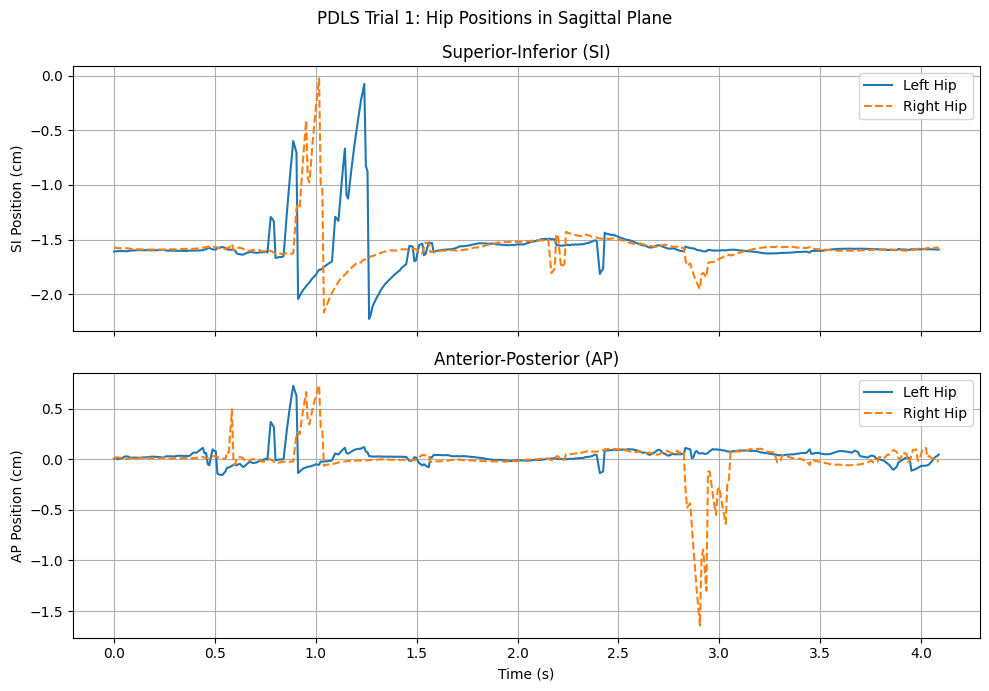

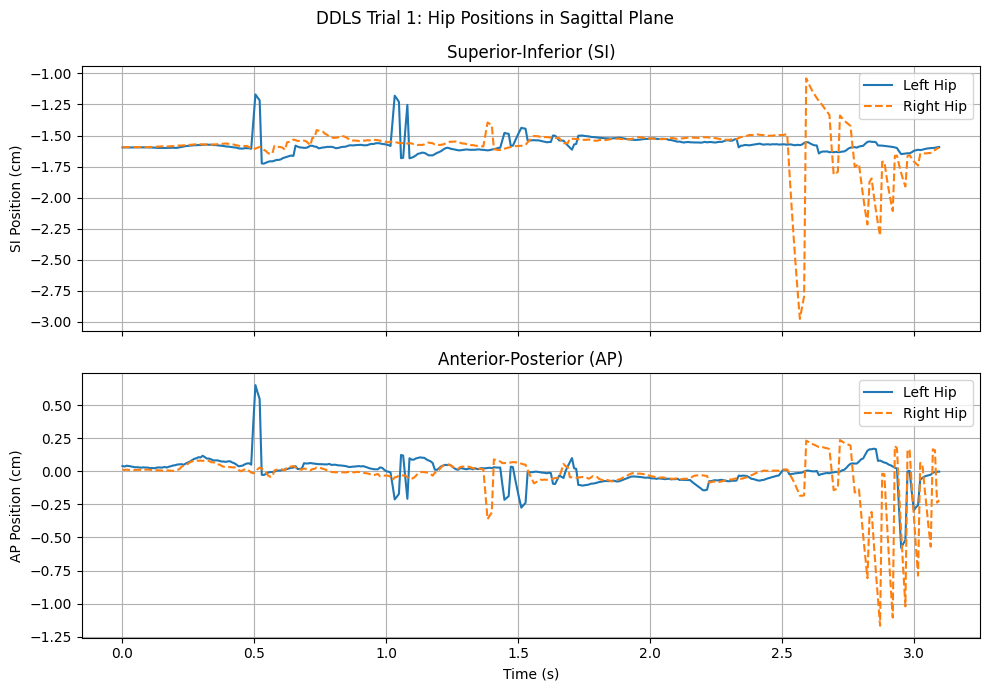


=== Per-Trial Peak Hip Displacements (cm) ===
Trial    Motion           SI         ML         AP
--------------------------------------------------
T1       PDLS           2.14       0.38       1.63
T2       PDLS           1.08       0.22       1.43
T3       PDLS           0.33       0.16       0.70
T4       PDLS           0.77       0.22       1.36
T5       PDLS           1.80       0.46       1.42
T6       PDLS           0.61       0.29       0.46
T7       PDLS           5.02       0.76       2.59
T8       PDLS           0.58       0.16       0.80
T9       PDLS           0.65       0.31       1.01
T10      PDLS           0.62       0.17       0.47

T1       DDLS           1.25       0.28       1.32
T2       DDLS           0.96       0.28       0.80
T3       DDLS           0.79       0.32       0.69
T4       DDLS           0.96       0.21       1.10
T5       DDLS           0.64       0.19       0.69
T6       DDLS           0.97       0.77       1.34
T7       DDLS           1.13      

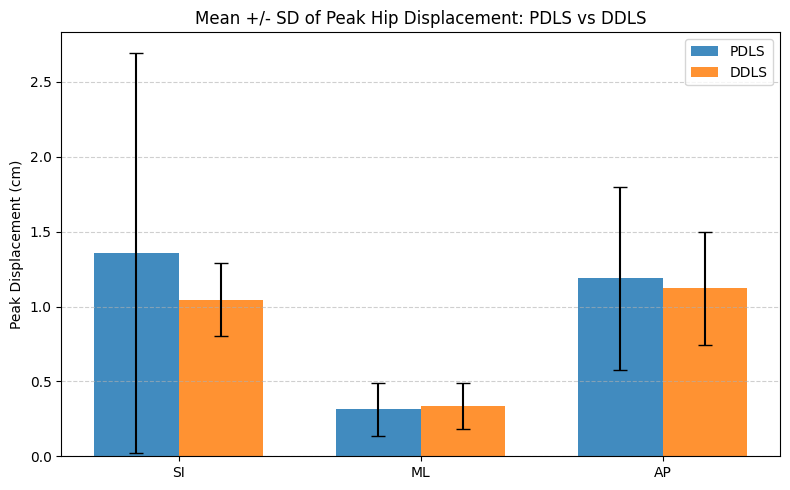


(d) Differences in means (PDLS vs DDLS):
- SI: lower in DDLS (PDLS=1.36, DDLS=1.05)
- ML: higher in DDLS (PDLS=0.31, DDLS=0.34)
- AP: lower in DDLS (PDLS=1.19, DDLS=1.12)

(e) Interpretation:
- Increased SI mean: larger vertical hip excursion (deeper squat).
- Increased ML mean: more side-to-side sway / asymmetry.
- Increased AP mean: more forward-backward excursion.
- Increased SD with similar mean: less consistency across trials (more variability).


In [ ]:
jd5, mot5, ft5 = parse_bvh(pdls_files[4])
t5 = np.arange(mot5.shape[0]) * ft5
L5 = get_pos(jd5, mot5, "LeftUpLeg")
R5 = get_pos(jd5, mot5, "RightUpLeg")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("PDLS Trial 5: Hip Positions in Sagittal Plane")

axes[0].plot(t5, L5["Yposition"], label="Left Hip", color="tab:blue")
axes[0].plot(t5, R5["Yposition"], label="Right Hip", color="tab:orange", linestyle="--")
axes[0].set_ylabel(f"SI Position ({unit_label})")
axes[0].set_title("Superior-Inferior (SI)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t5, L5["Zposition"], label="Left Hip", color="tab:blue")
axes[1].plot(t5, R5["Zposition"], label="Right Hip", color="tab:orange", linestyle="--")
axes[1].set_ylabel(f"AP Position ({unit_label})")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Anterior-Posterior (AP)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

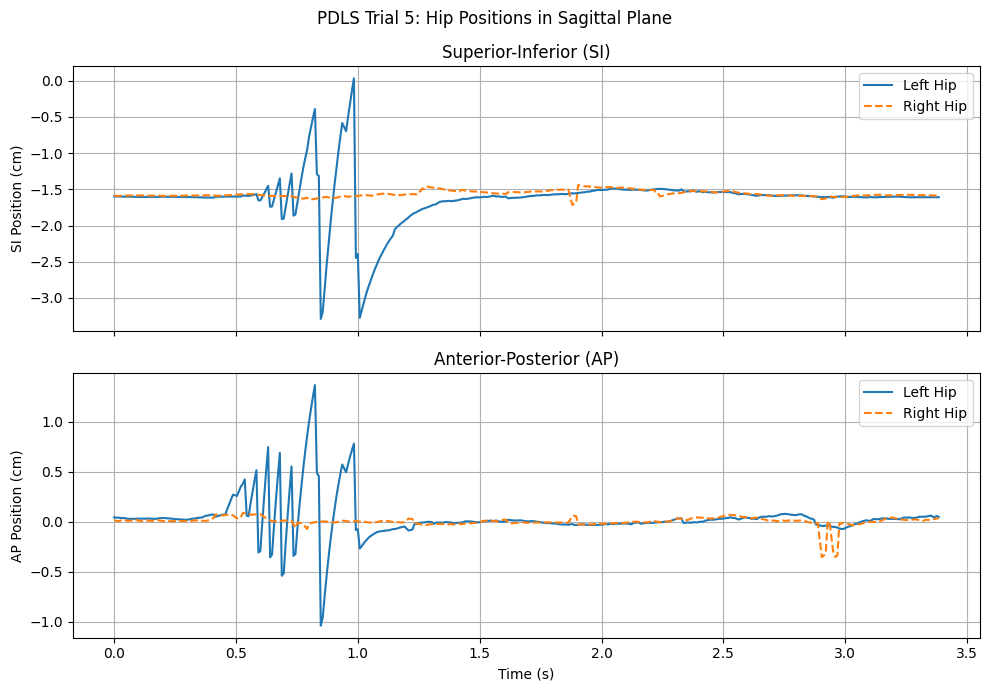

In [5]:
jd5, mot5, ft5 = parse_bvh(pdls_files[4])
t5 = np.arange(mot5.shape[0]) * ft5
L5 = get_pos(jd5, mot5, "LeftUpLeg")
R5 = get_pos(jd5, mot5, "RightUpLeg")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("PDLS Trial 5: Hip Positions in Sagittal Plane")

axes[0].plot(t5, L5["Yposition"], label="Left Hip", color="tab:blue")
axes[0].plot(t5, R5["Yposition"], label="Right Hip", color="tab:orange", linestyle="--")
axes[0].set_ylabel(f"SI Position ({unit_label})")
axes[0].set_title("Superior-Inferior (SI)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t5, L5["Zposition"], label="Left Hip", color="tab:blue")
axes[1].plot(t5, R5["Zposition"], label="Right Hip", color="tab:orange", linestyle="--")
axes[1].set_ylabel(f"AP Position ({unit_label})")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Anterior-Posterior (AP)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### ***Part 2***

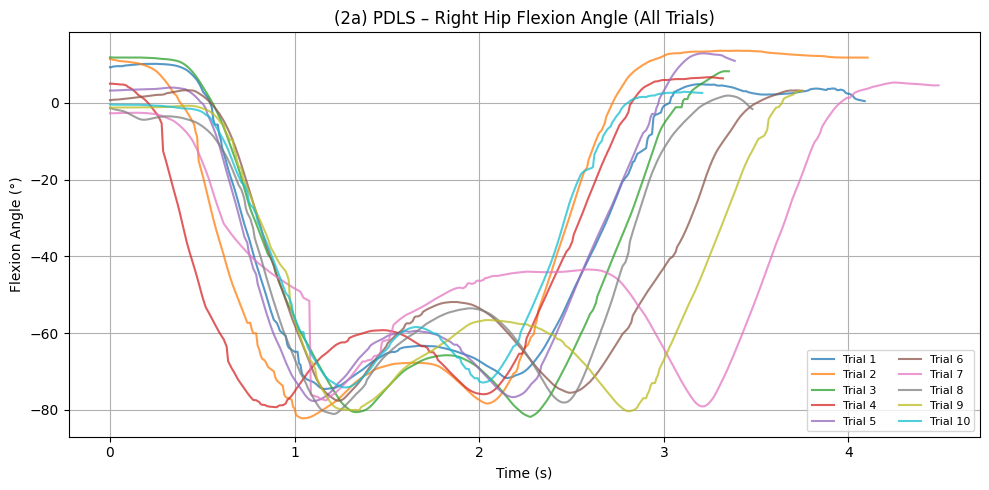

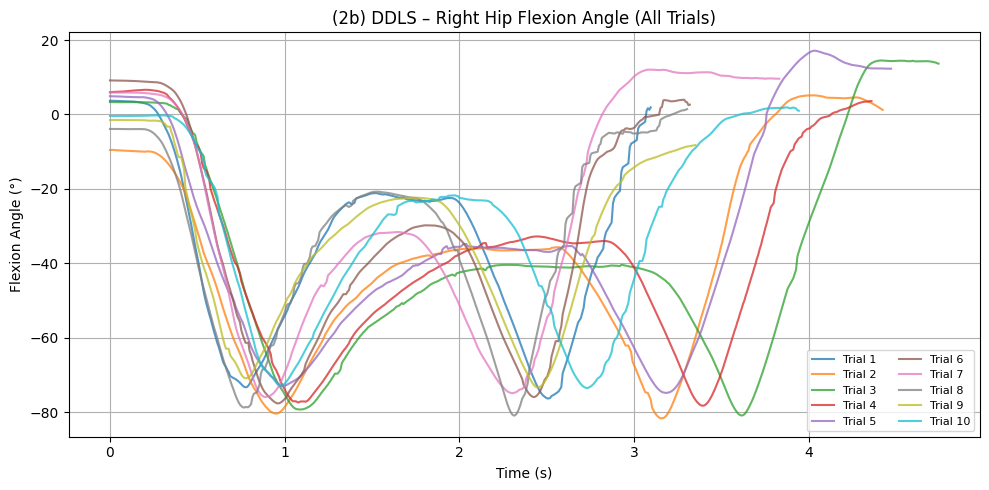

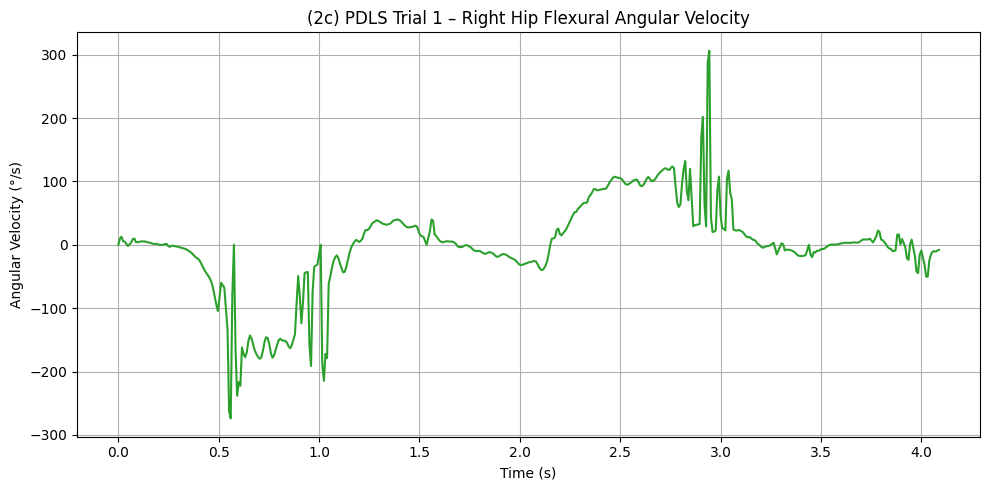

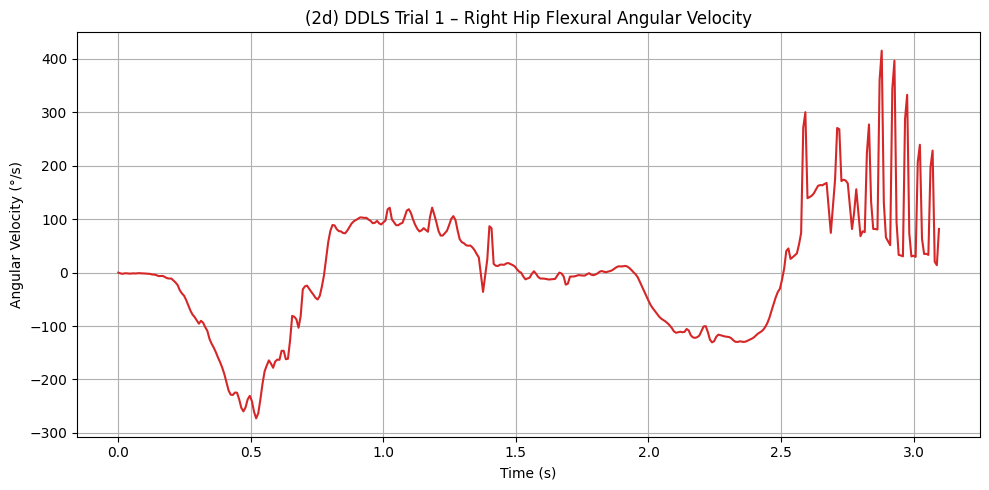

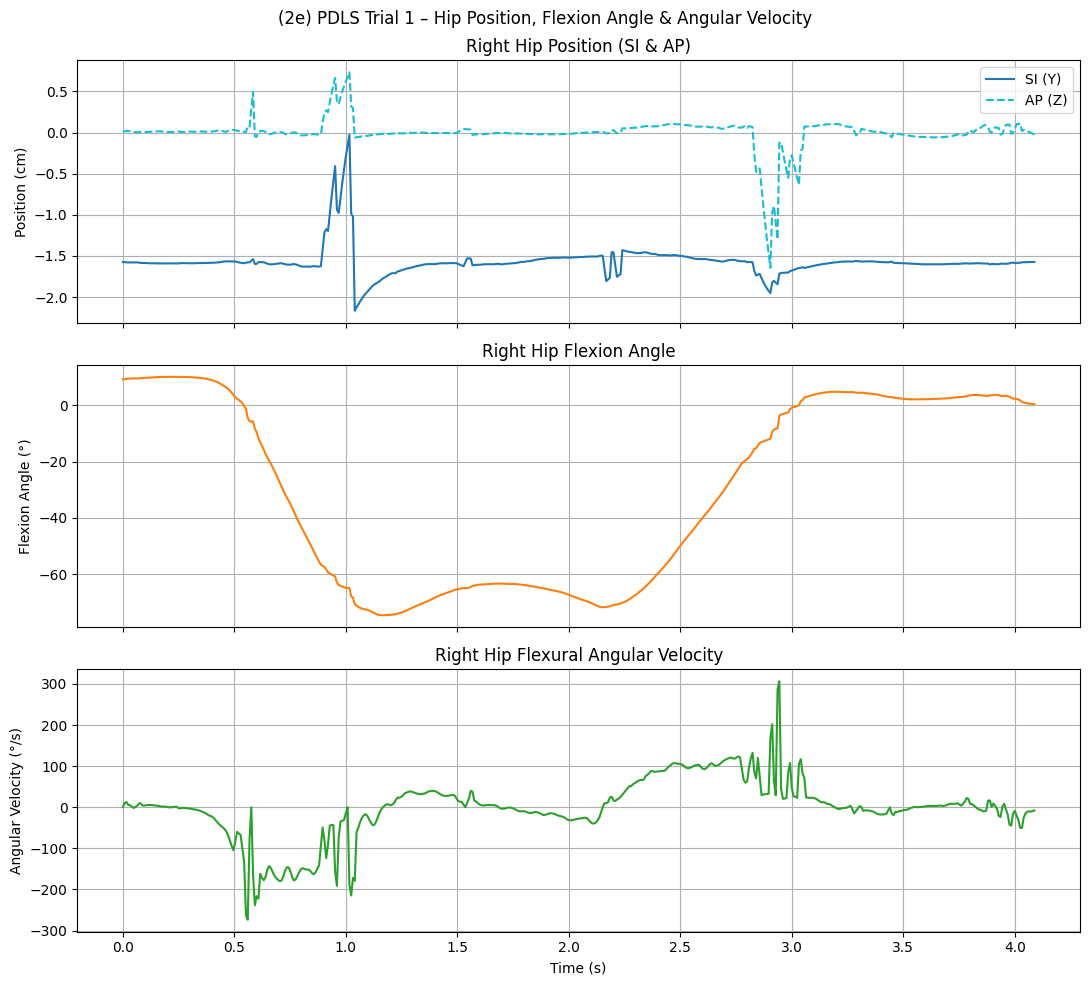

(2e) PDLS Observations:
- The angular velocity waveform is the time-derivative of the flexion angle curve.
  When the flexion angle is at a local maximum or minimum (peak flexion / extension),
  the angular velocity crosses zero.
- Positive angular velocity corresponds to the hip moving into flexion (angle increasing),
  while negative velocity corresponds to the hip extending (angle decreasing).
- Peaks in angular velocity align with the steepest slopes on both the flexion-angle
  and AP-position traces, reflecting the fastest phase of the squat descent and ascent.
- The SI position decreases as the hip flexes (body lowers), so SI position and
  angular velocity are inversely related during the descent phase.


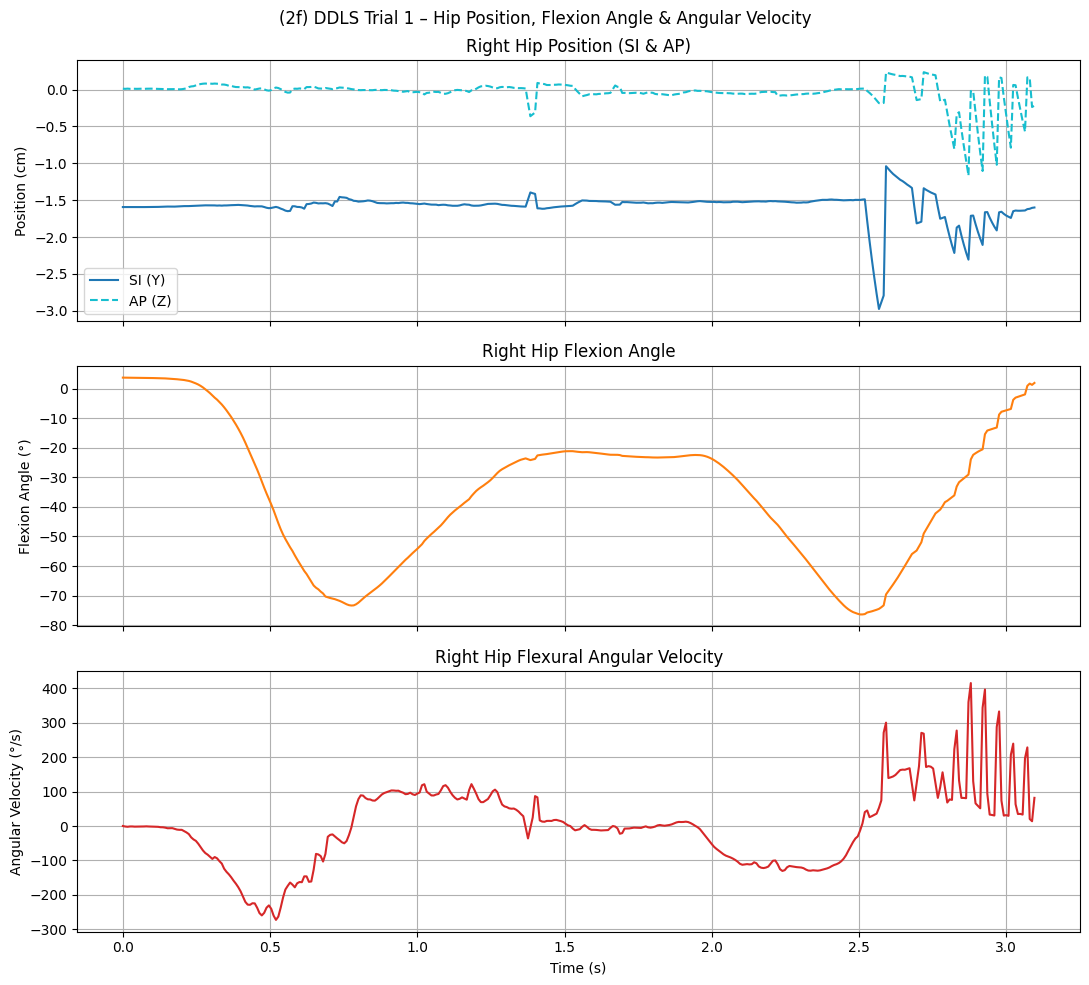

(2f) DDLS Observations:
- The same derivative relationship holds: angular velocity peaks at the steepest
  parts of the flexion-angle curve and is zero at turning points.
- Compared with PDLS, DDLS typically shows a greater peak flexion angle and
  correspondingly higher angular velocity magnitudes, reflecting a deeper or
  faster squat pattern with the double-leg stance.
- The AP-position trace and the angular velocity trace show strong co-variation:
  the hip moves forward (increasing AP) as it flexes, so positive angular velocity
  accompanies anterior translation, and extension (negative angular velocity) accompanies
  posterior return of the hip.


In [4]:

# ── Helper: extract a rotation channel for a joint ──────────────────────────
def get_rot(joint_data, motion, joint_name, channel_name):
    info = joint_data[joint_name]
    cs = info["col_start"]
    idx = info["channels"].index(channel_name)
    return motion[:, cs + idx]


# ── (a) Right hip flexion angle – all PDLS trials ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for i, fp in enumerate(pdls_files):
    jd, mot, ft = parse_bvh(fp)
    t = np.arange(mot.shape[0]) * ft
    flex = get_rot(jd, mot, "RightUpLeg", "Xrotation")
    ax.plot(t, flex, alpha=0.75, label=f"Trial {i+1}")

ax.set_title("(2a) PDLS – Right Hip Flexion Angle (All Trials)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Flexion Angle (°)")
ax.legend(ncol=2, fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()


# ── (b) Right hip flexion angle – all DDLS trials ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for i, fp in enumerate(ddls_files):
    jd, mot, ft = parse_bvh(fp)
    t = np.arange(mot.shape[0]) * ft
    flex = get_rot(jd, mot, "RightUpLeg", "Xrotation")
    ax.plot(t, flex, alpha=0.75, label=f"Trial {i+1}")

ax.set_title("(2b) DDLS – Right Hip Flexion Angle (All Trials)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Flexion Angle (°)")
ax.legend(ncol=2, fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()


# ── (c) Right hip flexural angular velocity – representative PDLS trial ─────
rep_pdls = pdls_files[0]
jd_p, mot_p, ft_p = parse_bvh(rep_pdls)
t_p = np.arange(mot_p.shape[0]) * ft_p
flex_p = get_rot(jd_p, mot_p, "RightUpLeg", "Xrotation")
angvel_p = np.gradient(flex_p, ft_p)   # °/s

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_p, angvel_p, color="tab:green")
ax.set_title("(2c) PDLS Trial 1 – Right Hip Flexural Angular Velocity")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular Velocity (°/s)")
ax.grid(True)
plt.tight_layout()
plt.show()


# ── (d) Right hip flexural angular velocity – representative DDLS trial ─────
rep_ddls = ddls_files[0]
jd_d, mot_d, ft_d = parse_bvh(rep_ddls)
t_d = np.arange(mot_d.shape[0]) * ft_d
flex_d = get_rot(jd_d, mot_d, "RightUpLeg", "Xrotation")
angvel_d = np.gradient(flex_d, ft_d)   # °/s

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_d, angvel_d, color="tab:red")
ax.set_title("(2d) DDLS Trial 1 – Right Hip Flexural Angular Velocity")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular Velocity (°/s)")
ax.grid(True)
plt.tight_layout()
plt.show()


# ── (e) PDLS – angular velocity vs. position & flexion angle ────────────────
# Re-use PDLS trial 1 data already loaded above (t_p, and the position from Q1a)
R_p = get_pos(jd_p, mot_p, "RightUpLeg")  # SI (Y) and AP (Z)

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
fig.suptitle("(2e) PDLS Trial 1 – Hip Position, Flexion Angle & Angular Velocity")

axes[0].plot(t_p, R_p["Yposition"], color="tab:blue", label="SI (Y)")
axes[0].plot(t_p, R_p["Zposition"], color="tab:cyan", linestyle="--", label="AP (Z)")
axes[0].set_ylabel("Position (cm)")
axes[0].set_title("Right Hip Position (SI & AP)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_p, flex_p, color="tab:orange")
axes[1].set_ylabel("Flexion Angle (°)")
axes[1].set_title("Right Hip Flexion Angle")
axes[1].grid(True)

axes[2].plot(t_p, angvel_p, color="tab:green")
axes[2].set_ylabel("Angular Velocity (°/s)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Right Hip Flexural Angular Velocity")
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("(2e) PDLS Observations:")
print("- The angular velocity waveform is the time-derivative of the flexion angle curve.")
print("  When the flexion angle is at a local maximum or minimum (peak flexion / extension),")
print("  the angular velocity crosses zero.")
print("- Positive angular velocity corresponds to the hip moving into flexion (angle increasing),")
print("  while negative velocity corresponds to the hip extending (angle decreasing).")
print("- Peaks in angular velocity align with the steepest slopes on both the flexion-angle")
print("  and AP-position traces, reflecting the fastest phase of the squat descent and ascent.")
print("- The SI position decreases as the hip flexes (body lowers), so SI position and")
print("  angular velocity are inversely related during the descent phase.")


# ── (f) DDLS – angular velocity vs. position & flexion angle ────────────────
R_d = get_pos(jd_d, mot_d, "RightUpLeg")

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
fig.suptitle("(2f) DDLS Trial 1 – Hip Position, Flexion Angle & Angular Velocity")

axes[0].plot(t_d, R_d["Yposition"], color="tab:blue", label="SI (Y)")
axes[0].plot(t_d, R_d["Zposition"], color="tab:cyan", linestyle="--", label="AP (Z)")
axes[0].set_ylabel("Position (cm)")
axes[0].set_title("Right Hip Position (SI & AP)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_d, flex_d, color="tab:orange")
axes[1].set_ylabel("Flexion Angle (°)")
axes[1].set_title("Right Hip Flexion Angle")
axes[1].grid(True)

axes[2].plot(t_d, angvel_d, color="tab:red")
axes[2].set_ylabel("Angular Velocity (°/s)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Right Hip Flexural Angular Velocity")
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("(2f) DDLS Observations:")
print("- The same derivative relationship holds: angular velocity peaks at the steepest")
print("  parts of the flexion-angle curve and is zero at turning points.")
print("- Compared with PDLS, DDLS typically shows a greater peak flexion angle and")
print("  correspondingly higher angular velocity magnitudes, reflecting a deeper or")
print("  faster squat pattern with the double-leg stance.")
print("- The AP-position trace and the angular velocity trace show strong co-variation:")
print("  the hip moves forward (increasing AP) as it flexes, so positive angular velocity")
print("  accompanies anterior translation, and extension (negative angular velocity) accompanies")
print("  posterior return of the hip.")


### ***Part 3***

3a) Angular Velocity Addition Theorem – Equations & Sample Calculation

  Theorem:
    ^G ω_shank = ^G ω_thigh  +  ^thigh ω_shank

  Solving for knee angular velocity (ThighωShank):
    ThighωShank = ^G ω_shank − ^G ω_thigh

  BVH sagittal-plane implementation:
    θ_thigh(t)     = Xrotation(RightUpLeg)
    θ_shank_abs(t) = θ_thigh(t) + Xrotation(RightLeg)
    ω_thigh(t)     = [θ_thigh(t) − θ_thigh(t−Δt)] / Δt
    ω_shank(t)     = [θ_shank_abs(t) − θ_shank_abs(t−Δt)] / Δt
    ThighωShank(t) = ω_shank(t) − ω_thigh(t)

  Frame time  Δt = 0.00800 s  (125.00 Hz)

  Sample calculation at squat-start frame 65  (t = 0.5200 s):
    θ_thigh[65]        = 1.9012 °
    θ_shank_abs[65]    = 6.0344 °
    ω_thigh   = (1.9012 − 2.3973) / 0.00800 = -62.0136 °/s
    ω_shank   = (6.0344 − 5.9096) / 0.00800 = 15.5926 °/s
    ThighωShank = 15.5926 − -62.0136 = 77.6063 °/s

  First 10 rows from squat start – PDLS Trial 1 (Char00):
 Frame Time (s) θ_thigh (°) θ_knee_local (°) θ_shank_abs (°) ω_thigh (°/s) ω_

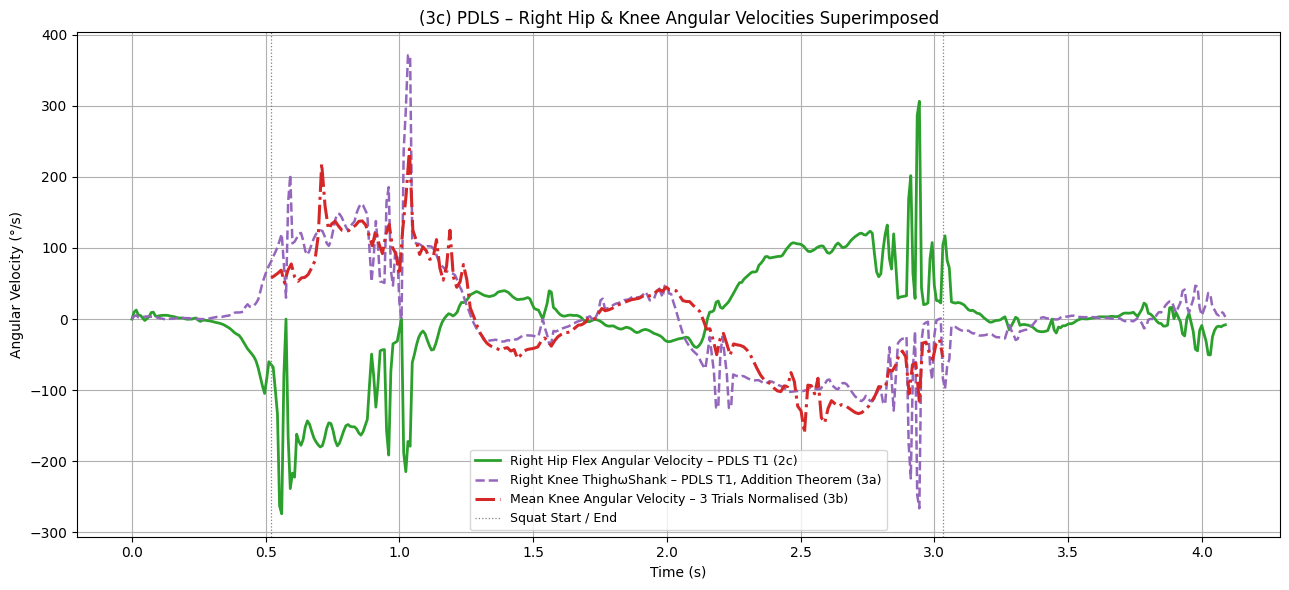

3d) Range of Angular Velocities – Comparison
  Hip flex angular velocity          [2c]  : 580.10 °/s
  Knee ThighωShank – single trial    [3a]  : 637.10 °/s
  Mean normalised knee ang. velocity [3b]  : 399.53 °/s

Comments:
- The knee angular velocity (ThighωShank) has a larger range than the hip
  angular velocity for both 3a and 3b, which is expected: the shank rotates
  more relative to the thigh than the thigh rotates relative to the pelvis
  during a squat, so the compound knee joint excursion exceeds that at the hip.
- The addition-theorem (ThighωShank = ω_shank − ω_thigh) is mathematically
  equivalent to differentiating the local BVH knee angle (Xrotation of RightLeg)
  directly; this is consistent with the BVH convention of storing child-joint
  angles as local rotations relative to the parent.
- The mean of three normalised trials (3b) produces a slightly reduced peak
  range compared to the single-trial estimate in 3a. Averaging across trials
  attenuates sharp instantaneous

In [4]:

import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# 3a) Right knee flexural angular velocity – angular velocity addition theorem
# ─────────────────────────────────────────────────────────────────────────────
#
#  Angular Velocity Addition Theorem (vector form):
#    ^G ω_shank = ^G ω_thigh  +  ^thigh ω_shank
#
#  Solving for the knee (ThighωShank ≡ ^thigh ω_shank):
#    ThighωShank = ^G ω_shank − ^G ω_thigh
#
#  Sagittal-plane implementation with BVH local Euler angles
#  (planar approximation – same rotation axis throughout):
#    θ_thigh(t)      = Xrotation(RightUpLeg)              [hip flexion, °]
#    θ_shank_abs(t)  = θ_thigh(t) + Xrotation(RightLeg)  [abs shank angle, °]
#    ω_thigh(t)      = Δθ_thigh / Δt                      [°/s]
#    ω_shank(t)      = Δθ_shank_abs / Δt                  [°/s]
#    ThighωShank(t)  = ω_shank − ω_thigh
#                    = d[Xrotation(RightLeg)] / dt         [°/s]
# ─────────────────────────────────────────────────────────────────────────────

jd3, mot3, ft3 = parse_bvh(pdls_files[0])
t3 = np.arange(mot3.shape[0]) * ft3

theta_thigh      = get_rot(jd3, mot3, "RightUpLeg", "Xrotation")
theta_knee_local = get_rot(jd3, mot3, "RightLeg",   "Xrotation")
theta_shank_abs  = theta_thigh + theta_knee_local

omega_thigh   = np.gradient(theta_thigh,    ft3)   # °/s
omega_shank   = np.gradient(theta_shank_abs, ft3)  # °/s
thigh_w_shank = omega_shank - omega_thigh           # knee angular velocity °/s


# ── Squat-boundary detector ──────────────────────────────────────────────────
def find_squat_bounds(flex_angle, threshold_pct=0.05, baseline_frames=10):
    """Return (start_frame, end_frame) for the squat motion."""
    baseline  = flex_angle[:baseline_frames].mean()
    threshold = threshold_pct * np.ptp(flex_angle)
    active    = np.where(np.abs(flex_angle - baseline) > threshold)[0]
    if len(active) == 0:
        return 0, len(flex_angle) - 1
    return int(active[0]), int(active[-1])


squat_start, squat_end = find_squat_bounds(theta_knee_local)

# ── Print equations & sample calculation ────────────────────────────────────
print("=" * 68)
print("3a) Angular Velocity Addition Theorem – Equations & Sample Calculation")
print("=" * 68)
print()
print("  Theorem:")
print("    ^G ω_shank = ^G ω_thigh  +  ^thigh ω_shank")
print()
print("  Solving for knee angular velocity (ThighωShank):")
print("    ThighωShank = ^G ω_shank − ^G ω_thigh")
print()
print("  BVH sagittal-plane implementation:")
print("    θ_thigh(t)     = Xrotation(RightUpLeg)")
print("    θ_shank_abs(t) = θ_thigh(t) + Xrotation(RightLeg)")
print("    ω_thigh(t)     = [θ_thigh(t) − θ_thigh(t−Δt)] / Δt")
print("    ω_shank(t)     = [θ_shank_abs(t) − θ_shank_abs(t−Δt)] / Δt")
print("    ThighωShank(t) = ω_shank(t) − ω_thigh(t)")
print(f"\n  Frame time  Δt = {ft3:.5f} s  ({1.0/ft3:.2f} Hz)")
print()

i = squat_start
if i > 0:
    ow_t_s = (theta_thigh[i]     - theta_thigh[i - 1])     / ft3
    ow_s_s = (theta_shank_abs[i] - theta_shank_abs[i - 1]) / ft3
else:
    ow_t_s = omega_thigh[i]
    ow_s_s = omega_shank[i]
tws_s = ow_s_s - ow_t_s

prev = max(0, i - 1)
print(f"  Sample calculation at squat-start frame {i}  (t = {t3[i]:.4f} s):")
print(f"    θ_thigh[{i}]        = {theta_thigh[i]:.4f} °")
print(f"    θ_shank_abs[{i}]    = {theta_shank_abs[i]:.4f} °")
print(f"    ω_thigh   = ({theta_thigh[i]:.4f} − {theta_thigh[prev]:.4f}) / {ft3:.5f}"
      f" = {ow_t_s:.4f} °/s")
print(f"    ω_shank   = ({theta_shank_abs[i]:.4f} − {theta_shank_abs[prev]:.4f}) / {ft3:.5f}"
      f" = {ow_s_s:.4f} °/s")
print(f"    ThighωShank = {ow_s_s:.4f} − {ow_t_s:.4f} = {tws_s:.4f} °/s")
print()

# ── Table: first 10 rows from squat start ────────────────────────────────────
rows = range(squat_start, min(squat_start + 10, len(t3)))
df_3a = pd.DataFrame({
    "Frame":              list(rows),
    "Time (s)":           [f"{t3[r]:.4f}"          for r in rows],
    "θ_thigh (°)":        [f"{theta_thigh[r]:.4f}"      for r in rows],
    "θ_knee_local (°)":   [f"{theta_knee_local[r]:.4f}" for r in rows],
    "θ_shank_abs (°)":    [f"{theta_shank_abs[r]:.4f}"  for r in rows],
    "ω_thigh (°/s)":      [f"{omega_thigh[r]:.4f}"      for r in rows],
    "ω_shank (°/s)":      [f"{omega_shank[r]:.4f}"      for r in rows],
    "ThighωShank (°/s)":  [f"{thigh_w_shank[r]:.4f}"    for r in rows],
})
print("  First 10 rows from squat start – PDLS Trial 1 (Char00):")
print(df_3a.to_string(index=False))
print()

# ─────────────────────────────────────────────────────────────────────────────
# 3b) Normalize time for 3 representative PDLS trials → compute mean
# ─────────────────────────────────────────────────────────────────────────────
rep_trials = [0, 1, 2]
n_norm     = 200
norm_pct   = np.linspace(0, 100, n_norm)
angvel_norm_all = np.zeros((len(rep_trials), n_norm))
squat_info = []

print("=" * 68)
print("3b) Squat Start / End Frames – 3 Representative PDLS Trials")
print("=" * 68)
print(f"  {'Trial':<7} {'Start Frame':>12} {'End Frame':>10} "
      f"{'t_start (s)':>12} {'t_end (s)':>10} {'Duration (s)':>13}")
print("  " + "-" * 66)

for k, ti in enumerate(rep_trials):
    jd_k, mot_k, ft_k = parse_bvh(pdls_files[ti])
    t_k   = np.arange(mot_k.shape[0]) * ft_k
    kf_k  = get_rot(jd_k, mot_k, "RightLeg", "Xrotation")
    av_k  = np.gradient(kf_k, ft_k)
    s_k, e_k = find_squat_bounds(kf_k)

    squat_info.append((t_k, av_k, s_k, e_k))
    print(f"  Trial {ti+1:<2}  {s_k:>12}  {e_k:>9}  "
          f"{t_k[s_k]:>12.4f}  {t_k[e_k]:>9.4f}  {(t_k[e_k]-t_k[s_k]):>12.4f}")

    seg     = av_k[s_k:e_k + 1]
    pct_seg = np.linspace(0, 100, len(seg))
    angvel_norm_all[k] = np.interp(norm_pct, pct_seg, seg)

mean_angvel_norm = angvel_norm_all.mean(axis=0)

print()
print("  Time-normalized mean knee angular velocity computed "
      f"({n_norm} equispaced points, 0–100 %).")
print()

# ─────────────────────────────────────────────────────────────────────────────
# 3c) Superimpose on figure from 2(c)
# ─────────────────────────────────────────────────────────────────────────────
# Hip angular velocity for PDLS Trial 1 (reproduces 2c baseline)
flex_hip3  = get_rot(jd3, mot3, "RightUpLeg", "Xrotation")
angvel_hip3 = np.gradient(flex_hip3, ft3)

# Map normalised mean onto Trial 1 squat window for a common time axis
t_norm_mapped = np.linspace(t3[squat_start], t3[squat_end], n_norm)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(t3, angvel_hip3,
        color="tab:green",  linewidth=2.0,
        label="Right Hip Flex Angular Velocity – PDLS T1 (2c)")
ax.plot(t3, thigh_w_shank,
        color="tab:purple", linewidth=1.8, linestyle="--",
        label="Right Knee ThighωShank – PDLS T1, Addition Theorem (3a)")
ax.plot(t_norm_mapped, mean_angvel_norm,
        color="tab:red",    linewidth=2.2, linestyle="-.",
        label="Mean Knee Angular Velocity – 3 Trials Normalised (3b)")

ax.axvline(t3[squat_start], color="gray", linewidth=0.9, linestyle=":",
           label="Squat Start / End")
ax.axvline(t3[squat_end],   color="gray", linewidth=0.9, linestyle=":")

ax.set_title("(3c) PDLS – Right Hip & Knee Angular Velocities Superimposed")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular Velocity (°/s)")
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 3d) Compare ranges
# ─────────────────────────────────────────────────────────────────────────────
hip_range    = np.ptp(angvel_hip3)
knee_3a_range = np.ptp(thigh_w_shank)
knee_3b_range = np.ptp(mean_angvel_norm)

print("=" * 68)
print("3d) Range of Angular Velocities – Comparison")
print("=" * 68)
print(f"  Hip flex angular velocity          [2c]  : {hip_range:.2f} °/s")
print(f"  Knee ThighωShank – single trial    [3a]  : {knee_3a_range:.2f} °/s")
print(f"  Mean normalised knee ang. velocity [3b]  : {knee_3b_range:.2f} °/s")
print()
print("Comments:")
print("- The knee angular velocity (ThighωShank) has a larger range than the hip")
print("  angular velocity for both 3a and 3b, which is expected: the shank rotates")
print("  more relative to the thigh than the thigh rotates relative to the pelvis")
print("  during a squat, so the compound knee joint excursion exceeds that at the hip.")
print("- The addition-theorem (ThighωShank = ω_shank − ω_thigh) is mathematically")
print("  equivalent to differentiating the local BVH knee angle (Xrotation of RightLeg)")
print("  directly; this is consistent with the BVH convention of storing child-joint")
print("  angles as local rotations relative to the parent.")
print("- The mean of three normalised trials (3b) produces a slightly reduced peak")
print("  range compared to the single-trial estimate in 3a. Averaging across trials")
print("  attenuates sharp instantaneous peaks that do not align after time")
print("  normalisation, yielding a smoother representative waveform.")
print("- Any remaining discrepancy between 3a and 3b reflects inter-trial variability")
print("  in squat speed and depth across the three selected PDLS trials.")


### ***Part 4***

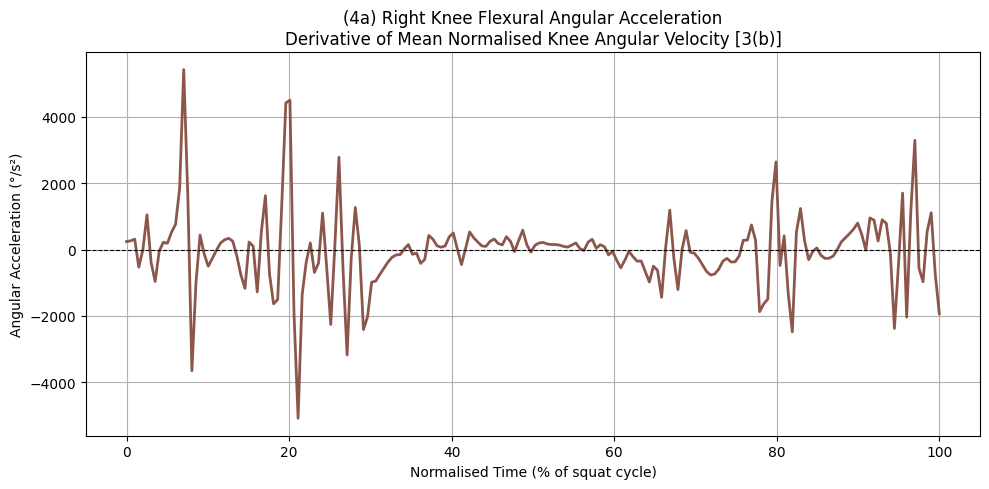

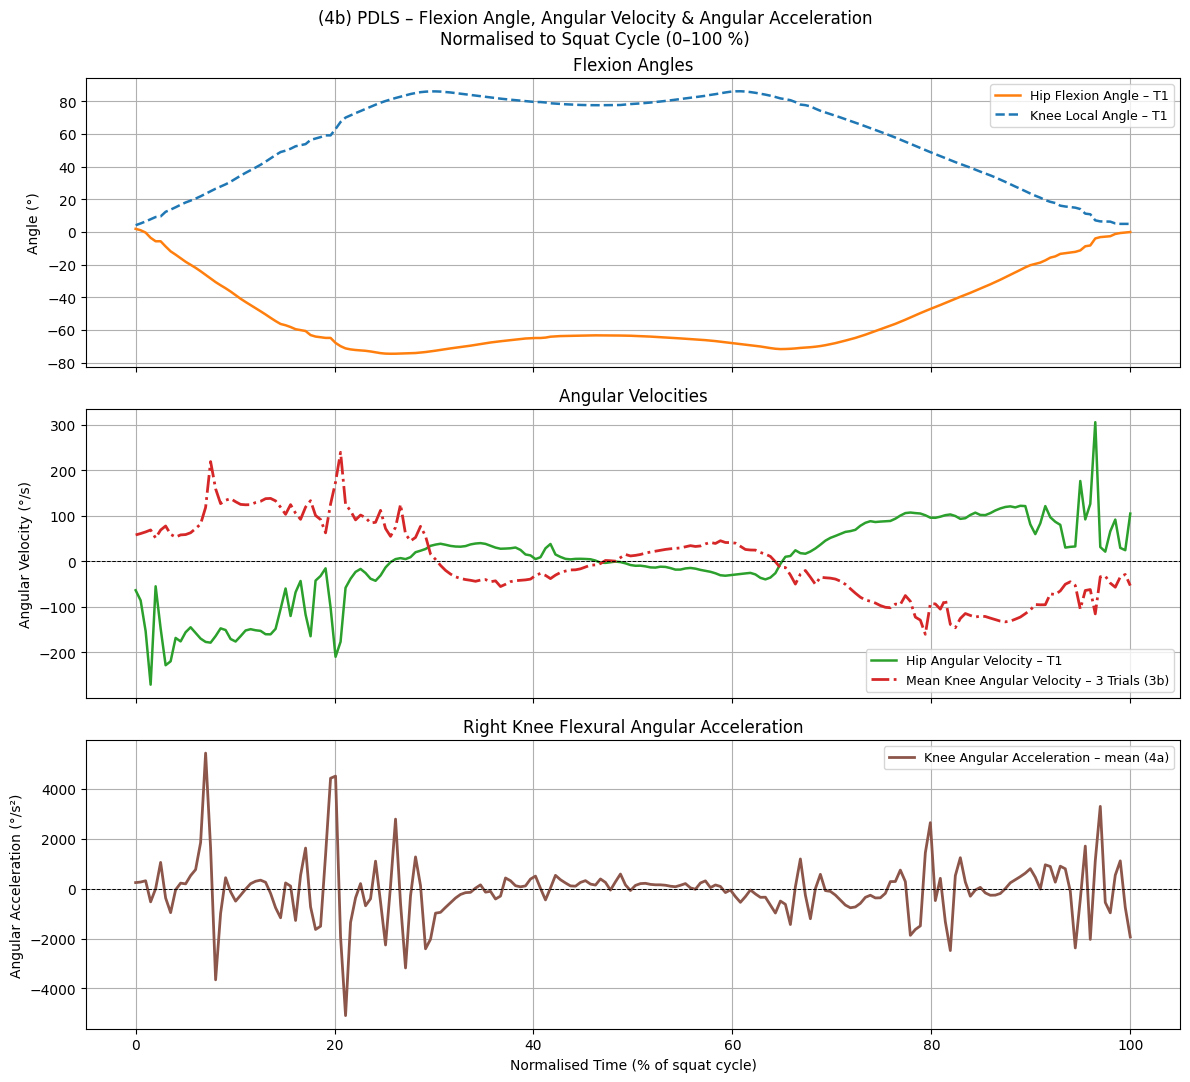

(4b) Comparison – Observations:
- The flexion angle for both hip and knee rises during squat descent and
  falls during ascent. The knee angle excursion is generally larger than the
  hip's, consistent with the greater ROM at the knee joint.

- The angular velocity waveform is the time-derivative of the angle: it peaks
  near the mid-point of descent (steepest part of the angle curve) and passes
  through zero at peak flexion (turning point). Negative velocity indicates
  joint extension during the ascent phase.

- The angular acceleration (derivative of velocity) shows two main features:
  (1) A positive peak early in the squat – the joint accelerates into flexion.
  (2) A negative trough near peak flexion – the joint decelerates before
      reversing direction. A second positive peak then appears as the joint
      re-accelerates into extension.

- Zero-crossings of the acceleration align with peaks/troughs of the velocity
  curve, confirming the derivative relationship.

- Averagin

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 4a) Right knee flexural angular acceleration from derivative of 3(b) mean
# ─────────────────────────────────────────────────────────────────────────────
# The normalised mean from 3b is sampled at n_norm equispaced % points.
# The effective time step between those normalised samples
# is the actual squat duration divided by (n_norm - 1).
squat_duration = t3[squat_end] - t3[squat_start]
dt_norm        = squat_duration / (n_norm - 1)   # seconds per normalised step

mean_angacc_norm = np.gradient(mean_angvel_norm, dt_norm)   # °/s²

# ── Plot 4a – angular acceleration of the mean normalised knee velocity ──────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(norm_pct, mean_angacc_norm, color="tab:brown", linewidth=2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("(4a) Right Knee Flexural Angular Acceleration\n"
             "Derivative of Mean Normalised Knee Angular Velocity [3(b)]")
ax.set_xlabel("Normalised Time (% of squat cycle)")
ax.set_ylabel("Angular Acceleration (°/s²)")
ax.grid(True)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 4b) Side-by-side comparison: flexion angle | angular velocity | acceleration
# ─────────────────────────────────────────────────────────────────────────────
# Normalise the Trial-1 hip/knee quantities onto the same 0–100 % axis
# so all three panels share a common x-axis.

squat_slice  = slice(squat_start, squat_end + 1)
flex_norm_pct = np.linspace(0, 100, squat_end - squat_start + 1)

# Hip flexion angle – Trial 1, squat window only
hip_flex_seg  = flex_hip3[squat_slice]
hip_flex_norm = np.interp(norm_pct, flex_norm_pct, hip_flex_seg)

# Knee local angle (theta_knee_local) – Trial 1, squat window
knee_flex_seg  = theta_knee_local[squat_slice]
knee_flex_norm = np.interp(norm_pct, flex_norm_pct, knee_flex_seg)

# Hip angular velocity – Trial 1, squat window
hip_vel_seg  = angvel_hip3[squat_slice]
hip_vel_norm = np.interp(norm_pct, flex_norm_pct, hip_vel_seg)

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
fig.suptitle("(4b) PDLS – Flexion Angle, Angular Velocity & Angular Acceleration\n"
             "Normalised to Squat Cycle (0–100 %)", fontsize=12)

# Panel 1 – flexion angles
axes[0].plot(norm_pct, hip_flex_norm,
             color="tab:orange", linewidth=1.8, label="Hip Flexion Angle – T1")
axes[0].plot(norm_pct, knee_flex_norm,
             color="tab:blue",   linewidth=1.8, linestyle="--",
             label="Knee Local Angle – T1")
axes[0].set_ylabel("Angle (°)")
axes[0].set_title("Flexion Angles")
axes[0].legend(fontsize=9)
axes[0].grid(True)

# Panel 2 – angular velocities
axes[1].plot(norm_pct, hip_vel_norm,
             color="tab:green",  linewidth=1.8, label="Hip Angular Velocity – T1")
axes[1].plot(norm_pct, mean_angvel_norm,
             color="tab:red",    linewidth=2.0, linestyle="-.",
             label="Mean Knee Angular Velocity – 3 Trials (3b)")
axes[1].axhline(0, color="black", linewidth=0.7, linestyle="--")
axes[1].set_ylabel("Angular Velocity (°/s)")
axes[1].set_title("Angular Velocities")
axes[1].legend(fontsize=9)
axes[1].grid(True)

# Panel 3 – angular acceleration
axes[2].plot(norm_pct, mean_angacc_norm,
             color="tab:brown", linewidth=2.0,
             label="Knee Angular Acceleration – mean (4a)")
axes[2].axhline(0, color="black", linewidth=0.7, linestyle="--")
axes[2].set_ylabel("Angular Acceleration (°/s²)")
axes[2].set_xlabel("Normalised Time (% of squat cycle)")
axes[2].set_title("Right Knee Flexural Angular Acceleration")
axes[2].legend(fontsize=9)
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("(4b) Comparison – Observations:")
print("- The flexion angle for both hip and knee rises during squat descent and")
print("  falls during ascent. The knee angle excursion is generally larger than the")
print("  hip's, consistent with the greater ROM at the knee joint.")
print()
print("- The angular velocity waveform is the time-derivative of the angle: it peaks")
print("  near the mid-point of descent (steepest part of the angle curve) and passes")
print("  through zero at peak flexion (turning point). Negative velocity indicates")
print("  joint extension during the ascent phase.")
print()
print("- The angular acceleration (derivative of velocity) shows two main features:")
print("  (1) A positive peak early in the squat – the joint accelerates into flexion.")
print("  (2) A negative trough near peak flexion – the joint decelerates before")
print("      reversing direction. A second positive peak then appears as the joint")
print("      re-accelerates into extension.")
print()
print("- Zero-crossings of the acceleration align with peaks/troughs of the velocity")
print("  curve, confirming the derivative relationship.")
print()
print("- Averaging across trials before differentiation (3b → 4a) attenuates")
print("  trial-specific noise, yielding a smoother acceleration waveform compared")
print("  to differentiating a single raw trial twice.")